Running AlievPanfilov on grid tri: 100%|██████████| 1/1 [00:00<00:00,  4.81it/s]


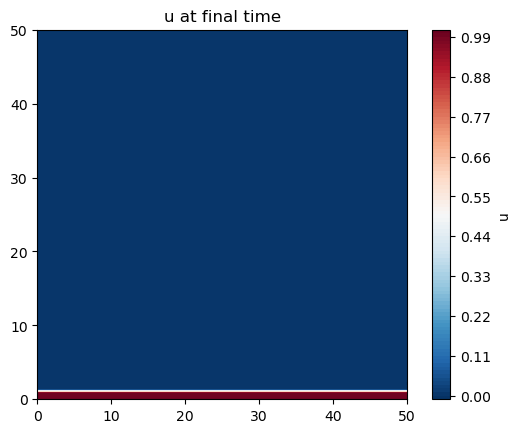

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import finitewave.elementalwave as fw


def build_triangular_mesh(n, m, x_range=(0, 1), y_range=(0, 1)):
    x = np.linspace(x_range[0], x_range[1], n+1)
    y = np.linspace(y_range[0], y_range[1], m+1)
    xv, yv = np.meshgrid(x, y)
    coords = np.vstack([xv.ravel(), yv.ravel(), np.zeros((n+1)*(m+1))]).T

    elems = []
    for j in range(m):
        for i in range(n):
            v0 = j * (n + 1) + i
            v1 = v0 + 1
            v2 = v0 + (n + 1)
            v3 = v2 + 1
            elems.append([v0, v1, v3])
            elems.append([v0, v3, v2])
    elems = np.array(elems)

    return coords, elems


# create a tissue of size 400x400 with cardiomycytes:
n = 400
size = 50

coords, elems = build_triangular_mesh(n, n, (0, size), (0, size))

tissue = fw.CardiacTissue(coords, elems)
# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoord(0, 1, 0, size, 0, 1))
stim_sequence.add_stim(fw.StimVoltageCoord(45, 1, 0, size//2, 0, size))


simulation = fw.CardiacSimulation()
# create model object and set up parameters:
simulation.cardiac_model = fw.AlievPanfilov()
simulation.dt = 0.01
simulation.t_max = 0.01
# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence

# run the model:
simulation.run()

u = simulation.cardiac_model.u

# show the potential map at the end of calculations:
plt.figure()
plt.tricontourf(coords[:, 0], coords[:, 1], elems, u, levels=100,
                cmap="RdBu_r")
plt.colorbar(label='u')
plt.title('u at final time')
plt.gca().set_aspect('equal')
plt.show()

In [2]:
res = simulation.diffusion_model.matrices

A = res[0]

A.size, A.shape

(1122401, (160801, 160801))

In [63]:
from numba import njit, prange


@njit(parallel=True, fastmath=True, cache=True)
def matvec_numba(u_new, u, rhs, indexes, indptr, indices, data):
    n_rows = indptr.size - 1

    for i in prange(n_rows):
        start, end = indptr[i], indptr[i + 1]
        if start == end:
            continue
        acc = 0.0
        for j in range(start, end):
            jj = indices[j]
            jj = indexes[jj]
            acc += data[j] * u.flat[jj]

        ii = indexes[i]
        u_new.flat[ii] = acc + rhs.flat[ii]

    return u_new

@njit(parallel=True, fastmath=True)
def matvec_and_dot_numba(indptr, indices, data, x, y, indexes):
    n = indptr.shape[0] - 1
    s = 0.
    for i in prange(n):
        start, end = indptr[i], indptr[i+1]
        if start == end:
            continue
        y_i = 0.
        for j in range(start, end):
            jj = indices[j]
            jj = indexes[jj]
            y_i += data[j] * x.flat[jj]
        
        ii = indexes[i]
        y.flat[ii] = y_i
        s += y_i * x.flat[ii]
    return y, s


@njit(parallel=True, fastmath=True)
def dot_numba(x, y, indexes):
    n = x.size
    s = 0.
    for i in prange(n):
        ii = indexes[i]
        s += x.flat[ii] * y.flat[ii]
    return s

@njit(parallel=True, fastmath=True)
def a_ypx_numba(a, x, y, indexes):
    n = x.size
    for i in prange(n):
        ii = indexes[i]
        y.flat[ii] = a * y.flat[ii] + x.flat[ii]
    return y


@njit(parallel=True, fastmath=True)
def a_xmy_numba(a, x, y, indexes):
    n = x.size
    for i in prange(n):
        ii = indexes[i]
        y.flat[ii] -= a * x.flat[ii]
    return y

@njit(parallel=True, fastmath=True)
def a_xpmy_numba(a, xp, yp, xm, ym, indexes):
    n = xp.size
    for i in prange(n):
        ii = indexes[i]
        yp.flat[ii] += a * xp.flat[ii]
        ym.flat[ii] -= a * xm.flat[ii]
    return yp, ym

def cg_numba(indptr, indices, data, b, x, indexes, atol=1e-6, maxiter=100):

    if np.sqrt(dot_numba(b, b, indexes)) == 0:
        return x, 0

    b0 = np.empty_like(x)
    b0, _ = matvec_and_dot_numba(indptr, indices, data, x, b0, indexes)
    r = b - b0
    q = np.empty_like(r)

    # Dummy value to initialize var, silences warnings
    rho_prev, p = None, None

    for iteration in range(maxiter):
        rho_cur = dot_numba(r, r, indexes)
        if np.sqrt(rho_cur) < atol:  # Are we done?
            return x, iteration

        if iteration > 0:
            beta = rho_cur / rho_prev
            p = a_ypx_numba(beta, r, p, indexes)
            # p *= beta
            # p += r
        else:  # First spin
            p = np.empty_like(r)
            p[:] = r[:]

        q, p_dot_q = matvec_and_dot_numba(indptr, indices, data, p, q, indexes)
        alpha = rho_cur / p_dot_q
        x, r = a_xpmy_numba(alpha, p, x, q, r, indexes)
        rho_prev = rho_cur

    return x, -1


In [64]:
from scipy import sparse as sp

x0 = u.copy()
x = u.copy()
b = np.random.random(u.shape)
indexes = np.arange(u.size)

x_numba, iters = cg_numba(A.indptr, A.indices, A.data, b, x, indexes, 1e-6, 3)
x_scipy, info = sp.linalg.cg(A, b, x0=x0, atol=1e-6, maxiter=3)

print(x_numba)
print(x_scipy)

[29.76162512 71.73549436 76.01154387 ... 15.96560724 55.86122757
 56.13472379]
[29.76162512 71.73549436 76.01154387 ... 15.96560724 55.86122757
 56.13472379]


In [65]:
import warnings
from threadpoolctl import threadpool_limits
from scipy.sparse import linalg


@threadpool_limits.wrap(limits=1, user_api="blas")
def cg_scipy(A, b, u, atol=1e-6, maxiter=100):
    u, success = linalg.cg(A, b, x0=u, atol=atol, rtol=0., maxiter=maxiter)
    if success > 0:
        warnings.warn("Diffusion kernel solution accuracy is not reached")
    return u


In [67]:
from scipy import sparse as sp

x0 = u.copy()
x = u.copy()
b = np.random.random(u.shape)
indexes = np.arange(u.size)

%timeit cg_numba(A.indptr, A.indices, A.data, b, x, indexes, 1e-6, 1)
%timeit cg_scipy(A, b, x, atol=1e-6, maxiter=1)

598 µs ± 8.59 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1 ms ± 22.4 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [5]:
import numpy as np

shape = (1000000, )

x = np.random.random(shape)
y = np.random.random(shape)
z = np.empty_like(x)

%timeit np.zeros_like(x)
%timeit np.empty_like(x)

701 µs ± 4.93 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
22.1 µs ± 901 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [35]:
%timeit A + 0.4 * A

4.79 ms ± 84.5 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [28]:
xm = np.random.random(u.shape)
ym = np.zeros_like(u)

xp = np.random.random(u.shape)
yp = np.zeros_like(u)

a_xpmy_numba(0.5, xp, yp, xm, ym)
a_xpy_numba(0.5, xp, yp)

%timeit y = yp - 0.5 * xp
%timeit a_xpy_numba(0.5, xp, yp)
%timeit a_xpmy_numba(0.5, xp, yp, xm, ym)


1.08 ms ± 201 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
440 µs ± 5.97 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
368 µs ± 1.62 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [30]:
x = np.random.random(u.shape)
y = np.empty_like(u)
%timeit np.empty_like(u)
%timeit y[:] = x[:]

425 ns ± 53.6 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
161 µs ± 4.64 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [2]:
import numpy as np


x = np.random.random((1000, 1000))
mesh = np.ones((1000, 1000))

coords = np.argwhere(mesh > 0)

mask = coords[:, 0] > 10

%timeit x.flat[mask] = 1

3.21 ms ± 88.9 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [11]:
def stimulate(mesh, u, slices, volt_value=1):
    roi_mesh = mesh[slices]
    mask = (roi_mesh == 1)

    u[slices][mask] = volt_value
    return u


def stimulate_mask(u, mesh, indices, volt_value=1):
    indices = indices[mesh.flat[indices] == 1]
    u.flat[indices] = volt_value
    return u


mesh = np.ones((1000, 1000))
u = np.random.random(mesh.shape)

x_min, x_max = 0, 100
y_min, y_max = 0, mesh.shape[0]
slices = (slice(x_min, x_max), slice(y_min, y_max))

coords = np.argwhere(mesh > 0)
mask = (coords[:, 0] >= x_min) & (coords[:, 0] < x_max) & (coords[:, 1] >= y_min) & (coords[:, 1] < y_max)
indexes = np.flatnonzero(mask)

%timeit stimulate(mesh, u, slices, 1)
%timeit stimulate_mask(u, mesh, indexes, 1)

58.4 µs ± 1.09 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
735 µs ± 6.4 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [10]:
q = np.random.random(u.shape[0]).astype(np.float64)
p = q.copy()
x = np.zeros_like(q)
y = np.zeros_like(q)

%timeit A @ q
%timeit csr_matvec(A.data, A.indices, A.indptr, x, y)

4.08 ms ± 30.8 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.67 ms ± 6.83 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [11]:
%timeit M.dot(q)
%timeit M @ q

2.67 ms ± 53.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.83 ms ± 64.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
import numpy as np

x = np.random.random((256, 256, 256))
y = np.random.random((256, 256, 256))

if x.ndim == 2:
    slices = (slice(100, 110), slice(100, 110))
elif x.ndim == 3:
    slices = (slice(100, 110), slice(100, 110), slice(100, 110))

%timeit x[slices]

38.9 ms ± 467 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [14]:
import numpy as np

class A:
    def __init__(self):
        self.state_vars = ["u", "v"]
        self.init_u = 0.
        self.init_v = 0.
        self.m = np.arange(5)

    def init_state_vars(self):
        for var in self.state_vars:
            val = getattr(self, "init_" + var)
            val = np.full_like(self.m, val)
            setattr(self, "_" + var, val)

    def __getattr__(self, name):
        if name in self.state_vars:
            return getattr(self, "_" + name)

    def __setattr__(self, name, value):
        """Allow assignment like a.u = new_array."""
        if "state_vars" in self.__dict__ and name in self.state_vars:
            setattr(self, "_" + name, value)
            return
        
        super().__setattr__(name, value)

a = A()
a.init_state_vars()

print(a.u)
print(a.v)

a.u = 1.
a.v = 2.

print(a.u)
print(a.v)

print(a._u)
print(a._v)




[0 0 0 0 0]
[0 0 0 0 0]
1.0
2.0
1.0
2.0


In [1]:
import numpy as np

import numba


@numba.njit(parallel=True)
def foo(x, y, indexes):
    for i in numba.prange(indexes.shape[0]):
        ind = indexes[i]
        x.flat[ind] = x.flat[ind] + np.sqrt(y.flat[ind]) + np.exp(x.flat[ind])

    return x

@numba.njit(parallel=True)
def foo_c(x, y):
    for i in numba.prange(x.size):
        x.flat[i] = x.flat[i] + np.sqrt(y.flat[i]) + np.exp(x.flat[i])

    return x

x = np.random.random((400, 400))
y = np.random.random((400, 400))
indexes = np.arange(400 * 400)

indexes = indexes[np.random.random(400 * 400) > 0.2].copy()

x_c = x.flat[indexes].copy()
y_c = y.flat[indexes].copy()

%timeit foo(x, y, indexes)
%timeit foo_c(x_c, y_c)

108 µs ± 13.2 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
123 µs ± 3 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [5]:
mesh = np.random.random((256, 256, 256)) > 0.9
mesh_ = mesh > 0

%timeit mesh == mesh_

%timeit np.flatnonzero(mesh > 0)

9.69 ms ± 195 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
16.5 ms ± 43.2 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
import numpy as np
from numba import njit, prange


@njit(parallel=True)
def calc_ecg_second_prange(tr_current, coords, dr, indexes, distance_power=1):
    n_j = tr_current.shape[1]

    n_c = len(coords)
    ecg = np.zeros(n_c)

    for c in range(n_c):
        x, y, z = coords[c]

        ecg_ = 0

        for ind in prange(len(indexes)):
            ii = indexes[ind]
            i = ii // n_j
            j = ii % n_j 

            d = np.sqrt((x - i)**2 + (y - j)**2 + (z)**2) ** distance_power

            if d > 0:
                ecg_ += tr_current[i, j] / (d * dr)

        ecg[c] = ecg_

    return ecg


@njit
def calc_power(val, power):
    if power == 2:
        return val

    return np.sqrt(val)

@njit(parallel=True)
def calc_ecg_prange(tr_current, coords, dr, i, j, k, distance_power=1):

    n_c = len(coords)
    ecg = np.zeros(n_c)

    for c in prange(n_c):
        x, y, z = coords[c]
        d = np.sqrt((x - i)**2 + (y - j)**2 + (z - k)**2) ** distance_power
        ecg[c] = np.sum(tr_current / (d * dr))

    return ecg



m = np.random.random((200, 200)) > 0.2
u = np.random.random((200, 200))
u_new = np.random.random((200, 200))
rhs = np.random.random((200, 200))

tr_current = np.random.random((200, 200))
coords = np.random.random((1000, 3)) + 1
dr = 1
indexes = np.flatnonzero(m > 0)

x, y = np.unravel_index(indexes, tr_current.shape)
z = np.zeros(len(indexes))
tr_current_ = tr_current[x, y]

%timeit np.unravel_index(indexes, m.shape)
%timeit tr_current = u - u_new - rhs


%timeit calc_ecg_second_prange(tr_current, coords, dr, indexes)
%timeit calc_ecg_first_prange(tr_current, coords, dr, indexes)
%timeit calc_ecg_prange(tr_current_, coords, dr, x, y, z)


46.3 µs ± 2.12 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
17.8 µs ± 22.2 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
49.9 ms ± 1.11 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
14.9 ms ± 560 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
11.4 ms ± 1.45 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [46]:
m = np.load("/Users/arstanbek/Projects/fibrosis/Finitewave/examples/data/mesh.npy")

u = np.random.random(m.shape)
u_new = np.random.random(m.shape)
rhs = np.random.random(m.shape)

indexes = np.flatnonzero(m > 0)
coords = np.zeros((1000, 3), dtype=np.int64)

i, j, k = np.unravel_index(indexes, m.shape)
tr_current = u[i, j, k]

%timeit np.unravel_index(indexes, m.shape)
%timeit tr_current = u - u_new - rhs
%timeit tr_current = u[i, j, k]
%timeit tr_current = u.flat[indexes]
%timeit calc_ecg_prange(tr_current, coords, dr, i, j, k)

15.1 ms ± 204 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
26 ms ± 167 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
24.8 ms ± 77.1 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
15 ms ± 390 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
981 ms ± 14.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [12]:
import jax.numpy as jnp
import numpy as np
import math
from numba import njit, prange


@njit
def fn_where(cond, x, y):
    if cond:
        return x
    return y

@njit
def numba_where(cond, x, y):
    return cond*x + (1 - cond)*y

@njit
def bar_numba(x, x_inf, tau_x, dt, exp=math.exp):
    return x_inf - (x_inf - x)*exp(-dt/tau_x)


@njit
def h_numba(h, u, dt, exp=math.exp, where=fn_where):    
    cond = u >= -40
    ah = where(cond, 0, 0.135*exp(-(80 + u)/6.8))
    bh = where(cond, 1/(0.13*(1 + exp(-(u + 10.66)/11.1))),
               3.56*exp(0.079*u) + 310000*exp(0.35*u))
    
    h_inf = ah/(ah + bh)
    tau_h = 1/(ah + bh)
    h = bar_numba(h, h_inf, tau_h, dt, exp)
    return h

@njit
def h_cond_numba(h, u, dt, exp=math.exp):
    cond = u >= -40
    ah = numba_where(cond, 0, 0.135*exp(-(80 + u)/6.8))
    bh = numba_where(cond, 1/(0.13*(1 + exp(-(u + 10.66)/11.1))),
                     3.56*exp(0.079*u) + 310000*exp(0.35*u))
    
    h_inf = ah/(ah + bh)
    tau_h = 1/(ah + bh)
    h = bar_numba(h, h_inf, tau_h, dt, exp)
    return h


@njit(parallel=True, fastmath=True)
def h_numba_parallel(h, u, dt, exp=math.exp):
    for i in prange(len(u)):
        h[i] = h_numba(h[i], u[i], dt, exp, numba_where)
    return h


@njit(parallel=True, fastmath=True)
def h_cond_numba_parallel(h, u, dt, indexes, exp=math.exp):
    for ind in prange(len(indexes)):
        i = indexes[ind]
        h[i] = h_cond_numba(h[i], u[i], dt, exp)
    return h


u = np.random.random(1_000_000)
h = np.zeros(1_000_000)
dt = 0.01
mask = u > 0.2
indexes = np.flatnonzero(mask)

%timeit h_numba_parallel(h, u, dt)
%timeit h_cond_numba_parallel(h, u, dt, indexes)


4.46 ms ± 63.5 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
3.9 ms ± 164 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [13]:
def bar_numpy(x, x_inf, tau_x, dt, exp=np.exp):
    return x_inf + (x - x_inf)*exp(-dt/tau_x)


def h_cond_numpy(h, u, dt, exp=np.exp):
    cond = u >= -40
    ah = np.where(cond, 0, 0.135*exp(-(80 + u)/6.8))
    bh = np.where(cond, 1/(0.13*(1 + exp(-(u + 10.66)/11.1))),
                  3.56*exp(0.079*u) + 310000*exp(0.35*u))
    
    h_inf = ah/(ah + bh)
    tau_h = 1/(ah + bh)
    h = bar_numpy(h, h_inf, tau_h, dt, exp)
    return h


%timeit h_cond_numpy(h, u, dt)

34.6 ms ± 1.46 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [15]:
import jax
import jax.numpy as jnp
from functools import partial


@partial(jax.jit, static_argnames=('exp',))
def bar_jax(x, x_inf, tau_x, dt, exp=jnp.exp):
    return x_inf + (x - x_inf)*exp(-dt/tau_x)


@partial(jax.jit, static_argnames=('exp',))
def h_cond_jax(h, u, dt, exp=jnp.exp):
    cond = u >= -40
    ah = jnp.where(cond, 0, 0.135*exp(-(80 + u)/6.8))
    bh = jnp.where(cond, 1/(0.13*(1 + exp(-(u + 10.66)/11.1))),
                      3.56*exp(0.079*u) + 310000*exp(0.35*u))
    
    h_inf = ah/(ah + bh)
    tau_h = 1/(ah + bh)
    h = bar_jax(h, h_inf, tau_h, dt)
    return h


@partial(jax.jit, static_argnames=('exp',))
def h_cond_jax_mask(h, u, dt, mask, exp=jnp.exp):
    h += jnp.where(mask, h_cond_jax(h, u, dt, exp), 0)
    return h


u = np.random.random(1000_000)
h = np.zeros(1000_000)
dt = 0.01
mask = u > 0.2

h_jax = jnp.array(h)
u_jax = jnp.array(u)
%timeit h_cond_jax(h, u, dt, exp=jnp.exp)
%timeit h_cond_jax_mask(h_jax, u_jax, dt, mask, exp=jnp.exp)

2.58 ms ± 30.4 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.54 ms ± 15.1 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
@partial(jax.jit, static_argnames=('exp',))
def h_cond_jax_indexes(h, u, dt, indexes, exp=jnp.exp):
    u = u.at[indexes].get()
    cond = u >= -40
    ah = jnp.where(cond, 0, 0.135*exp(-(80 + u)/6.8))
    bh = jnp.where(cond, 1/(0.13*(1 + exp(-(u + 10.66)/11.1))),
                   3.56*exp(0.079*u) + 310000*exp(0.35*u))
    
    h_inf = ah/(ah + bh)
    tau_h = 1/(ah + bh)
    h = bar_jax(h, h_inf, tau_h, dt)
    
    return h

u_large = np.random.random(1000_000)
inds = np.random.choice(1000_000, size=950_000, replace=False)
h = np.zeros(950_000)
dt = 0.01

mask = np.zeros_like(u_large, dtype=bool)
mask[inds] = True

h_jax = jnp.array(h)
u_jax = jnp.array(u_large)
mask = jnp.array(mask)
# %timeit h_cond_jax_mask(h_jax, u_jax, dt, mask, exp=jnp.exp)
%timeit h_cond_jax_indexes(h_jax, u_jax, dt, inds, exp=jnp.exp)

3.06 ms ± 21.7 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
%timeit 

4.99 ms ± 603 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [23]:
import numpy as np
import jax.numpy as jnp


u_large = np.random.random(3000_000)
inds = np.random.choice(3000_000, 1000_000)
h = np.zeros(1000_000)


# @jax.jit
# def jnp_take(u_large, inds):
#     return jnp.take(u_large, inds)

u_jax = jnp.array(u_large)
h_jax = jnp.array(h)
inds_jax = jnp.array(inds)

%timeit u_jax.at[inds_jax].set(h_jax)
%timeit u_large[inds] = h


2.62 ms ± 259 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.2 ms ± 13.2 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [3]:
import numpy as np

x = np.random.random(1000_000)
b = np.random.random(1000_000)

%timeit y = 10 * x

706 µs ± 14.9 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [3]:
from numba import prange, njit
from threadpoolctl import threadpool_limits


@njit(parallel=True, fastmath=True)
def diffusion_numba(u_new, u, weighs, indexes):
    n_j = u.shape[1]
    n_k = u.shape[2]
    for i in prange(indexes.shape[0]):
        ind = indexes[i]
        i = ind//(n_j*n_k)
        j = (ind % (n_j*n_k))//n_k
        k = (ind % (n_j*n_k)) % n_k
        u_new[i, j, k] += (weighs[i, j, k, 0] * u[i + 1, j, k] + 
                           weighs[i, j, k, 1] * u[i - 1, j, k] +
                           weighs[i, j, k, 2] * u[i, j + 1, k] +
                           weighs[i, j, k, 3] * u[i, j - 1, k] +
                           weighs[i, j, k, 4] * u[i, j, k + 1] +
                           weighs[i, j, k, 5] * u[i, j, k - 1] + 
                           weighs[i, j, k, 6] * u[i, j, k])

    return u_new


@threadpool_limits.wrap(limits=1, user_api="blas")
def diffusion_sparse_scipy(A, u):
    return A @ u


In [74]:
import scipy.sparse as sp
import jax.numpy as jnp
from jax.experimental import sparse as jsparse

mesh = np.ones((200, 200, 20))
mesh[0, :, :] = 0
mesh[-1, :, :] = 0
mesh[:, 0, :] = 0
mesh[:, -1, :] = 0
mesh[:, :, 0] = 0
mesh[:, :, -1] = 0

indexes = np.flatnonzero(mesh > 0)
c_indexes = np.arange(len(indexes))


def create_matrix(mesh):
    rows, cols, data = [], [], []
    weighs = np.zeros((*mesh.shape, 7), dtype=np.float64)

    for i in range(mesh.shape[0]):
        for j in range(mesh.shape[1]):
            for k in range(mesh.shape[2]):
                if mesh[i, j, k] > 0:
                    for di in [-1, 1]:
                        rows.append([i, j, k])
                        cols.append([i + di, j, k])
                        data.append(1)
                
                    weighs[i+1, j, k, 0] = 1
                    weighs[i-1, j, k, 1] = 1

                    for dj in [-1, 1]:
                        rows.append([i, j, k])
                        cols.append([i, j + dj, k])
                        data.append(1)
                    
                    weighs[i, j+1, k, 2] = 1
                    weighs[i, j-1, k, 3] = 1

                    for dk in [-1, 1]:
                        rows.append([i, j, k])
                        cols.append([i, j, k + dk])
                        data.append(1)
                    
                    weighs[i, j, k+1, 4] = 1
                    weighs[i, j, k-1, 5] = 1


                    rows.append([i, j, k])
                    cols.append([i, j, k])
                    data.append(-6)

                    weighs[i, j, k, 6] = -6

    rows = np.array(rows).T
    cols = np.array(cols).T

    rows = np.ravel_multi_index(rows, mesh.shape)
    cols = np.ravel_multi_index(cols, mesh.shape)
    data = np.array(data)
    a_scipy = sp.coo_matrix((data, (rows, cols)), shape=(mesh.size, mesh.size))
    a_scipy = a_scipy.tocsr()
    return a_scipy, weighs


a_scipy, weighs = create_matrix(mesh)

b_numpy = np.array(mesh, dtype=np.float64)
b_new = np.zeros_like(b_numpy)
b_flat = b_numpy.flatten()

x = diffusion_numba(b_new, b_numpy, weighs, indexes)
x = diffusion_sparse_scipy(a_scipy, b_flat)

%timeit x = diffusion_sparse_scipy(a_scipy, b_flat)
%timeit x = diffusion_numba(b_new, b_numpy, weighs, indexes)

8.02 ms ± 378 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.87 ms ± 48.3 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [1]:
from numba import prange, njit
from threadpoolctl import threadpool_limits


@njit(parallel=True, fastmath=True)
def diffusion_numba(u_new, u, weighs, indexes):
    n_j = u.shape[1]
    n_k = u.shape[2]
    for i in prange(indexes.shape[0]):
        ind = indexes[i]
        i = ind//(n_j*n_k)
        j = (ind % (n_j*n_k))//n_k
        k = (ind % (n_j*n_k)) % n_k
        u_new[i, j, k] += (weighs[i, j, k, 0] * u[i + 1, j, k] + 
                           weighs[i, j, k, 1] * u[i - 1, j, k] +
                           weighs[i, j, k, 2] * u[i, j + 1, k] +
                           weighs[i, j, k, 3] * u[i, j - 1, k] +
                           weighs[i, j, k, 4] * u[i, j, k + 1] +
                           weighs[i, j, k, 5] * u[i, j, k - 1] + 
                           weighs[i, j, k, 6] * u[i, j, k])

    return u_new


@njit(parallel=True, fastmath=True)
def diffusion_sparse_numba(indptr, indices, data, u_new, u):
    n_rows = indptr.size - 1
    
    for i in prange(n_rows):
        start = indptr[i]
        end = indptr[i + 1]
        acc = 0.0
        for j in range(start, end):
            acc += data[j] * u[indices[j]]
        u_new[i] = acc
    
    return u_new


@threadpool_limits.wrap(limits=1, user_api="blas")
def diffusion_sparse_scipy(A, u):
    return A @ u


In [2]:
from pathlib import Path
import numpy as np
import scipy.sparse as sp


def create_matrix(mesh, indexes):
    weighs = np.zeros((*mesh.shape, 7), dtype=np.float64)

    n_j = mesh.shape[1]
    n_k = mesh.shape[2]
    for i in range(indexes.shape[0]):
        ind = indexes[i]
        i = ind//(n_j*n_k)
        j = (ind % (n_j*n_k))//n_k
        k = (ind % (n_j*n_k)) % n_k
        
        w_central = 0

        if mesh[i+1, j, k] > 0:
            weighs[i+1, j, k, 0] = mesh[i+1, j, k]
            w_central += mesh[i+1, j, k]
        
        if mesh[i-1, j, k] > 0:
            weighs[i-1, j, k, 1] = mesh[i-1, j, k]
            w_central += mesh[i-1, j, k]

        if mesh[i, j + 1, k] > 0:
            weighs[i, j + 1, k, 2] = mesh[i, j + 1, k]
            w_central += mesh[i, j + 1, k]
        
        if mesh[i, j-1, k] > 0:
            weighs[i, j-1, k, 3] = mesh[i, j-1, k]
            w_central += mesh[i, j-1, k]

        if mesh[i, j, k+1] > 0:
            weighs[i, j, k+1, 4] = mesh[i, j, k+1]
            w_central += mesh[i, j, k+1]

        if mesh[i, j, k-1] > 0:
            weighs[i, j, k-1, 5] = mesh[i, j, k-1]
            w_central += mesh[i, j, k-1]

        weighs[i, j, k, 6] = -w_central

    return weighs                   


def create_sparse_matrix(mesh, indexes):
    rows = []
    cols = []
    data = []

    ijk = np.argwhere(mesh > 0)

    for i_axis in range(len(mesh.shape)):
        for di in [-1, 1]:
            ii = ijk.copy()
            ii[:, i_axis] += di
            mask = mesh[tuple(ii.T)] > 0

            rows.append(np.ravel_multi_index(ijk[mask].T, mesh.shape))
            cols.append(np.ravel_multi_index(ii[mask].T, mesh.shape))
            data.append(mesh[tuple(ii[mask].T)])

    rows = np.concatenate(rows)
    cols = np.concatenate(cols)
    data = np.concatenate(data)

    # c_indexes = np.zeros(mesh.size, dtype=np.int64)
    # c_indexes[indexes] = np.arange(len(indexes))
    # rows = c_indexes[rows]
    # cols = c_indexes[cols]
    # size = len(indexes)
    size = mesh.size
    shape = (size, size)

    a_scipy = sp.coo_matrix((data, (rows, cols)),
                            shape=shape)
    diags = np.zeros(size, dtype=np.float64)
    # add diagonal as -sum of row
    diags = -a_scipy.sum(axis=1).A1
    a_scipy = a_scipy + sp.diags(diags, 0)
    a_scipy = a_scipy.tocsr()
    return a_scipy


path = Path("/Users/arstanbek/Projects/fibrosis/Finitewave/examples/data/mesh.npy")

# mesh = np.load(path)
# indexes = np.flatnonzero(mesh)

mesh = np.ones((200, 200, 20))
mesh[0, :, :] = 0
mesh[-1, :, :] = 0
mesh[:, 0, :] = 0
mesh[:, -1, :] = 0
mesh[:, :, 0] = 0
mesh[:, :, -1] = 0

indexes = np.flatnonzero(mesh)

a_scipy = create_sparse_matrix(mesh, indexes)
weighs = create_matrix(mesh, indexes)

b_numpy = np.array(mesh, dtype=np.float64)
b_new = np.zeros_like(b_numpy)
b_flat = b_numpy.flatten()
b_new_flat = b_new.flatten()

# x = diffusion_sparse_scipy(a_scipy, b_flat)
x = diffusion_numba(b_new, b_numpy, weighs, indexes)
x = diffusion_sparse_numba(a_scipy.indptr, a_scipy.indices, a_scipy.data, b_new_flat, b_flat)

# %timeit x = diffusion_sparse_scipy(a_scipy, b_flat)
%timeit x = diffusion_numba(b_new, b_numpy, weighs, indexes)
%timeit x = diffusion_sparse_numba(a_scipy.indptr, a_scipy.indices, a_scipy.data, b_new_flat, b_flat)

243 μs ± 15.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
232 μs ± 14.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [ ]:
indexes = self.simulation.cardiac_model.myo_indexes
i, j, k = self.unravel_index(indexes, u.shape)

tr_current = (u - u_prev - rhs).flat[indexes] / dt
ecg = calc_ecg(tr_current, self.measure_coords, i, j, k, dr,
self.distance_power)
return ecg

5.37 ms ± 203 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
4.59 ms ± 109 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [6]:
from pathlib import Path
import numpy as np


path = Path("/Users/arstanbek/Projects/fibrosis/FibrosisOptimization/data/models/left_ventricle/LV")
# Load mesh as cubic array
mesh = np.load(path.joinpath("0", "tissue.npy"))

mask = mesh > 0
u = np.random.random(mesh.shape)[mask]
u_prev = np.random.random(mesh.shape)[mask]
rhs = np.random.random(mesh.shape)[mask]
# indexes = np.flatnonzero(mesh > 0)
indexes = np.arange(u.size)
ind_mask = indexes > len(indexes) * 0.2
dt = 0.01

%timeit tr_current = (u - u_prev - rhs).flat[indexes] / dt
%timeit tr_current = (u - u_prev - rhs)[ind_mask] / dt
%timeit i, j, k = np.unravel_index(indexes, mesh.shape)

16.5 ms ± 682 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
8.2 ms ± 25.6 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
13 ms ± 64.2 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [51]:
u.astype(np.float32).nbytes

15383008

In [ ]:
x, y, z

In [20]:
from pathlib import Path
from numba import njit, prange
import numpy as np


@njit(parallel=True, fastmath=True)
def calc_ecg(tr_current, coords, i, j, k, dr, distance_power=1):

    n_c = len(coords)
    ecg = np.zeros(n_c, dtype=tr_current.dtype)

    for c in prange(n_c):
        x, y, z = coords[c]
        d = np.sqrt((x - i)**2 + (y - j)**2 + (z - k)**2) ** distance_power
        ecg[c] = np.sum(tr_current / (d * dr))

    return ecg

path = Path("/Users/arstanbek/Projects/fibrosis/FibrosisOptimization/data/models/left_ventricle/LV")
# Load mesh as cubic array
mesh = np.load(path.joinpath("0", "tissue.npy"))
mask = mesh > 0

electrodes_epi = np.load(path.joinpath("electrodes_epi.npy"))
electrodes_endo = np.load(path.joinpath("electrodes_endo.npy"))
coords = np.vstack((electrodes_epi, electrodes_endo))[:, :3]


indexes = np.flatnonzero(mesh > 0)
tr_current = np.random.random(indexes.shape)

i, j, k = np.unravel_index(indexes, mesh.shape)
dr = 1.0
dt = 0.01

_ = calc_ecg(tr_current, coords, i, j, k, dr, distance_power=1)
%timeit ecg = calc_ecg(tr_current, coords, i, j, k, dr)

1.12 s ± 73.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [2]:
import jax.numpy as jnp
import jax


@jax.jit
def calc_ecg_jax(tr_current, coords, i, j, k, dr, distance_power=1):
    n_c = coords.shape[0]
    ecg = jnp.zeros(n_c)

    for c in range(n_c):
        x, y, z = coords[c]
        d = jnp.sqrt((x - i)**2 + (y - j)**2 + (z - k)**2) ** distance_power
        temp = tr_current / (d * dr)
        ecg_ = jnp.sum(temp)
        ecg.at[c].set(ecg_)

    return ecg


coords_jax = jnp.array(coords)
i_jax = jnp.array(i)
j_jax = jnp.array(j)
k_jax = jnp.array(k)
tr_jax = jnp.array(tr_current)
dr = 1.0

_ = calc_ecg_jax(tr_jax, coords_jax, i_jax, j_jax, k_jax, dr)
%timeit ecg = calc_ecg_jax(tr_jax, coords_jax, i_jax, j_jax, k_jax, dr)

5.13 µs ± 23.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [4]:
%timeit jnp.sqrt(coords_jax[0, 0] - i_jax)**2 + (coords_jax[0, 1] - j_jax)**2 + (coords_jax[0, 2] - k_jax)**2


4.6 ms ± 34.4 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
